<a href="https://colab.research.google.com/github/dac012/ValeraSanchezMontes-RL/blob/main/Entornos_Complejos/metodosTabulares.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Estudio comparativo de métodos tabulares

*Description:* El experimento compara el rendimiento de algoritmos tabulares en el entorno de Taxi.

    Authors: David Valera López
             Lucía Sánchez Montes Gómez

    Emails: d.valeralopez1@um.es
            lucia.s1@um.es

In [ ]:
# Copiar el repositorio. 
!git clone https://github.com/dac012/ValeraSanchezMontes-RL.git
!cd ValeraSanchezMontes-RL/

En este notebook vamos a estudiar distintos **métodos tabulares de control en aprendizaje por refuerzo**.

En los métodos tabulares, el agente aprende directamente una **tabla de valores acción-estado**:

\[
Q(s,a)
\]

donde cada par **estado-acción** tiene asociado un valor que representa el retorno esperado al seguir una determinada política.

Este enfoque es viable cuando el **espacio de estados es pequeño y discreto**, ya que la tabla puede almacenarse completamente en memoria.

En este notebook compararemos varios algoritmos clásicos de control tabular utilizando el entorno **Taxi-v3**.

In [ ]:
# Importamos las librerías necesarias
from src.agents import AgentMonteCarloOnPolicy, AgentMonteCarloOffPolicy, AgentSARSA, AgentQLearning
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from gymnasium.wrappers import RecordVideo
from IPython.display import Video, display


# Fijamos la semilla para reproducibilidad
seed = 42
np.random.seed(seed)
np.random.default_rng(seed)

# Fijamos la semilla en Gymnasium
def make_env(env_name):
    env = gym.make(env_name, render_mode='None')
    env.reset(seed=seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    return env

n_episodes = 50000

# Métricas utilizadas

Para comparar el comportamiento de los distintos agentes durante el entrenamiento
se utilizan las siguientes tres métricas:

## Proporción acumulada de éxitos

Mide la fracción de episodios completados con éxito hasta el episodio \(t\):

$$
\text{ratio}(t) =
\frac{\sum_{i=1}^{t} \mathbb{1}(\text{éxito}_i)}{t}
$$

Gracias a esta métrica podemos visualizar:

- Si el agente converge a una política que resuelve el entorno.
- Qué algoritmo aprende antes.

## Longitud del episodio (número de pasos)

Indica cuántos pasos necesita el agente para terminar un episodio.

- Si el agente aprende una buena estrategia, normalmente necesita menos pasos.
- Además, en algunos entornos cuando el episodio termina antes es porque el agente alcanza el objetivo (éxito). Este es el caso de **Acrobot**.

## Media acumulada del return

Aproxima el rendimiento esperado de la política:

$$
J(\pi) = \mathbb{E}[G_t]
$$
Durante el entrenamiento se muestra la **media acumulada del return**, que actúa
como un promedio histórico del rendimiento.

Esto permite:

- observar la tendencia global del aprendizaje,
- comparar la **estabilidad entre algoritmos**,

En conjunto, estas tres métricas permiten visualizar lo esperado
por la teoría de control en **MDPs**: una política mejor maximiza el retorno esperado
y reduce el comportamiento erróneo durante la interacción con el entorno.

In [ ]:
# Lista de colores para usar en las gráficas para que se vean y distingan mejor
COLORS = [
    "#1f77b4",  
    "#ff7f0e",  
    "#2ca02c", 
    "#d62728",  
    "#9467bd",  
    "#8c564b"  
]


def moving_average(data, window=50):
    data = np.array(data, dtype=float)

    if len(data) < window:
        return data

    return np.convolve(data, np.ones(window) / window, mode='valid')


def plot_success_ratio(final_results, window=50):
    plt.figure(figsize=(8, 4))

    for i, (name, data) in enumerate(final_results.items()):
        color = COLORS[i % len(COLORS)]

        successes = np.array(data["list_stats_success"], dtype=float)
        cumulative_ratio = np.cumsum(successes) / np.arange(1, len(successes) + 1)

        # Línea original
        plt.plot(cumulative_ratio, alpha=0.25, color=color)

        # Media móvil
        avg = moving_average(cumulative_ratio, window)
        if len(cumulative_ratio) >= window:
            x_avg = np.arange(window - 1, len(cumulative_ratio))
        else:
            x_avg = np.arange(len(avg))

        plt.plot(x_avg, avg, linewidth=2.5, color=color, label=name)

    plt.title("Proporción acumulada de éxitos")
    plt.xlabel("Episodio")
    plt.ylabel("Proporción de éxitos")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_episode_length(final_results, window=50):
    plt.figure(figsize=(10, 5))

    for i, (name, data) in enumerate(final_results.items()):
        color = COLORS[i % len(COLORS)]

        y = np.array(data["episode_lengths"], dtype=float)
        x = np.arange(len(y))

        plt.plot(x, y, alpha=0.2, color=color)

        avg = moving_average(y, window)
        if len(y) >= window:
            x_avg = np.arange(window - 1, len(y))
        else:
            x_avg = np.arange(len(avg))

        plt.plot(x_avg, avg, linewidth=2.5, color=color, label=name)

    plt.title("Longitud de episodios")
    plt.xlabel("Episodio")
    plt.ylabel("Steps")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_global_avg(final_results, window=50):
    plt.figure(figsize=(8, 4))

    for i, (name, data) in enumerate(final_results.items()):
        color = COLORS[i % len(COLORS)]

        y = np.array(data["list_stats"], dtype=float)
        x = np.arange(len(y))

        plt.plot(x, y, alpha=0.25, color=color)

        avg = moving_average(y, window)
        if len(y) >= window:
            x_avg = np.arange(window - 1, len(y))
        else:
            x_avg = np.arange(len(avg))

        plt.plot(x_avg, avg, linewidth=2.5, color=color, label=name)

    plt.title("Media acumulada del return")
    plt.xlabel("Episodio")
    plt.ylabel("Return medio acumulado")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_all_results(final_results, window=50):
    plot_success_ratio(final_results, window)
    plot_episode_length(final_results, window)
    plot_global_avg(final_results, window)

# Entorno en el que trabajamos: Taxi-v3

El entorno que hemos decidido usar es **Taxi-v3**, de la librería **Gymnasium**.

Este entorno es ideal para estudiar **métodos tabulares**, ya que tanto el espacio
de estados como el espacio de acciones son **discretos y finitos**.

Gracias a esto, el agente puede aprender directamente la tabla \(Q(s,a)\) del entorno sin necesidad
de utilizar aproximación de funciones.

## ¿Qué es Taxi-v3?

En Taxi-v3, un taxi debe:

1. desplazarse por una cuadrícula,
2. recoger a un pasajero en una localización dada,
3. transportarlo hasta su destino correcto.

## Estado

El estado del entorno se codifica de manera discreta a partir de:

- la posición del taxi,
- la localización del pasajero,
- el destino final.

Esto genera un conjunto finito de estados, por lo que es viable almacenar y actualizar todos los valores de \(Q(s,a)\) en una tabla.

## Acciones

El espacio de acciones también es discreto y se pueden realizar un total de **6 acciones**:

- **0** → moverse al sur
- **1** → moverse al norte
- **2** → moverse al este
- **3** → moverse al oeste
- **4** → recoger pasajero
- **5** → dejar pasajero

## Recompensa y terminación

En Taxi-v3, el agente recibe:

- una penalización de **-1** por cada paso,
- una penalización adicional de **-10** si intenta recoger o dejar al pasajero de forma incorrecta,
- una recompensa de **+20** cuando completa correctamente la tarea.

El episodio termina cuando el pasajero es dejado en el destino correcto o cuando se alcanza el límite máximo de pasos.

Este diseño hace que una buena política sea aquella que completa la tarea con el menor número de acciones posibles y evitando errores. Normalmente el agente converge a políticas que resuelven el problema en aproximadamente **13–15 pasos**.

# Algoritmos comparados: Monte Carlo, SARSA y Q-Learning

En este notebook se entrenan los siguientes agentes:

- **Monte Carlo On-Policy**
- **Monte Carlo Off-Policy**
- **SARSA**
- **Q-Learning**

## Monte Carlo

Los métodos Monte Carlo aprenden a partir de **episodios completos**.

La actualización se basa en el retorno observado al final del episodio:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left(G_t - Q(s,a)\right)
$$

Son métodos conceptualmente simples, pero tienen que esperar hasta el final del episodio para actualizar y suelen presentar mayor varianza.

### Monte Carlo On-Policy

Aprende evaluando y mejorando la misma política que utiliza para comportarse.

### Monte Carlo Off-Policy

Permite aprender una política objetivo distinta de la política de comportamiento,
normalmente utilizando **muestreo por importancia**.

## SARSA

SARSA es un método **TD on-policy** que actualiza la función \(Q\) usando la acción que realmente está ejecutando el agente:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma Q(s',a') - Q(s,a)\right]
$$

El aprendizaje depende directamente de la política que está ejecutando el agente.

## Q-Learning

Q-Learning es un método **TD off-policy**.

La actualización utiliza la mejor acción posible en el siguiente estado:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]
$$

Esto permite aprender la política óptima incluso si el agente explora utilizando otra política.

In [28]:
# Creamos un entorno independiente para cada agente
envMonteCarloOnPolicy = make_env("Taxi-v3")
envMonteCarloOffPolicy = make_env("Taxi-v3")
envSARSA = make_env("Taxi-v3")
envQLearning = make_env("Taxi-v3")

# Inicializamos los agentes
agentMonteCarloOnPolicy = AgentMonteCarloOnPolicy(envMonteCarloOnPolicy)
agentMonteCarloOffPolicy = AgentMonteCarloOffPolicy(envMonteCarloOffPolicy)
agentSARSA = AgentSARSA(envSARSA)
agentQLearning = AgentQLearning(envQLearning)

step_display = n_episodes // 10  

agents_and_envs = [
    ("MC On-Policy", agentMonteCarloOnPolicy, envMonteCarloOnPolicy),
    ("MC Off-Policy", agentMonteCarloOffPolicy, envMonteCarloOffPolicy),
    ("SARSA", agentSARSA, envSARSA),
    ("Q-Learning", agentQLearning, envQLearning)
]

# Definimos diccionario donde guardaremos los resultados obtenidos con los agentes
final_results = {}

# Bucle de entrenamiento
for episode in tqdm(range(n_episodes)):
    
    # Entrenamos a cada agente un episodio completo en su respectivo entorno
    for name, agent, env in agents_and_envs:

        # Reiniciamos el entorno al inicio del episodio para obtener más diversidad 
        state, info = env.reset(seed=seed)
        done = False
        
        while not done:
            # El agente decide la acción
            action = agent.get_action(state)
            
            # El entorno da un paso y obtenemos los resultados del agente
            next_state, reward, terminated, truncated, info = env.step(action)
            
            # Actualizamos el agente
            agent.update(state, action, next_state, reward, terminated, truncated, info)
            
            # Comprobamos si el episodio ha terminado y avanzamos el estado
            done = terminated or truncated
            state = next_state
            
        # Mostramos la evolución en el terminal para cada agente
        if episode % step_display == 0 and episode != 0:
            print(f"[{name}] success: {agent.stats / episode:.4f}, epsilon: {agent.epsilon:.4f}")

# Guardamos resultados finales de cada agente
for name, agent, env in agents_and_envs:
    Q, list_stats, episode_lengths, list_stats_success = agent.get_stats()
    
    final_results[name] = {
        "Q": Q,
        "list_stats": list_stats,
        "episode_lengths": episode_lengths,
        "list_stats_success": list_stats_success
    }
    
    # Cerramos el entorno de este agente
    env.close()

 10%|█         | 5026/50000 [00:38<02:41, 278.21it/s]

[MC On-Policy] success: -41.3706, epsilon: 0.4000
[MC Off-Policy] success: -22.7718, epsilon: 0.1000
[SARSA] success: -235.1950, epsilon: 0.2000
[Q-Learning] success: -206.4498, epsilon: 0.2000


 20%|██        | 10032/50000 [00:58<02:15, 295.63it/s]

[MC On-Policy] success: -34.8539, epsilon: 0.4000
[MC Off-Policy] success: -10.1905, epsilon: 0.1000
[SARSA] success: -117.7671, epsilon: 0.1000
[Q-Learning] success: -103.3313, epsilon: 0.1000


 30%|███       | 15037/50000 [01:17<02:05, 278.77it/s]

...

 80%|████████  | 40028/50000 [02:53<00:33, 294.22it/s]

[MC On-Policy] success: -29.8094, epsilon: 0.4000
[MC Off-Policy] success: -0.6950, epsilon: 0.1000
[SARSA] success: -25.2801, epsilon: 0.0250
[Q-Learning] success: -21.6219, epsilon: 0.0250


 90%|█████████ | 45062/50000 [03:11<00:14, 337.09it/s]

[MC On-Policy] success: -29.6553, epsilon: 0.4000
[MC Off-Policy] success: -0.3390, epsilon: 0.1000
[SARSA] success: -21.7194, epsilon: 0.0222
[Q-Learning] success: -18.4606, epsilon: 0.0222


100%|██████████| 50000/50000 [03:26<00:00, 242.09it/s]


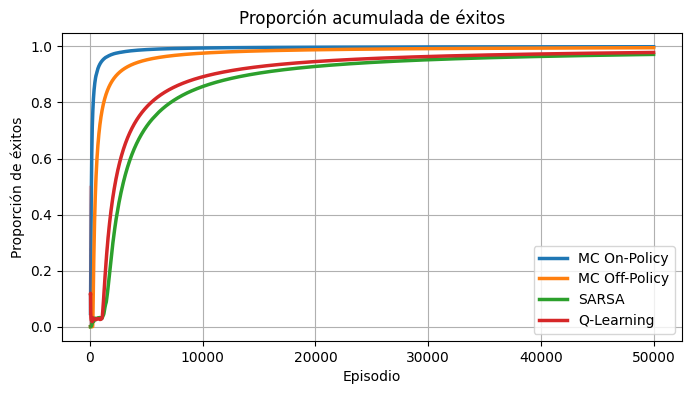

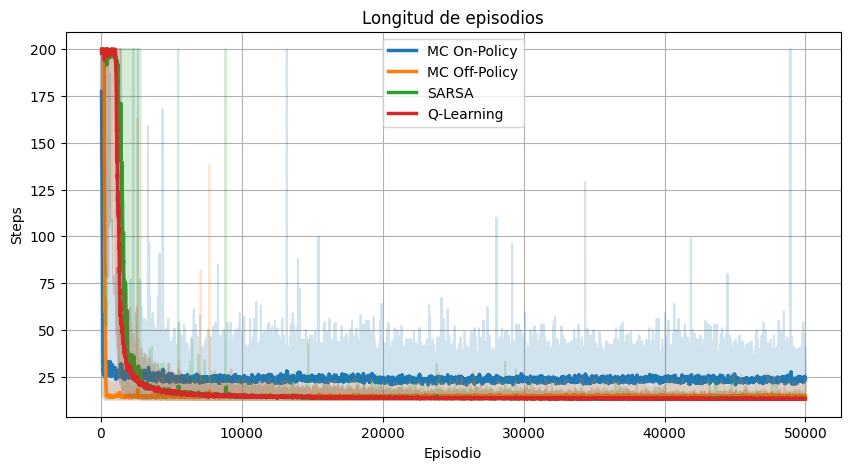

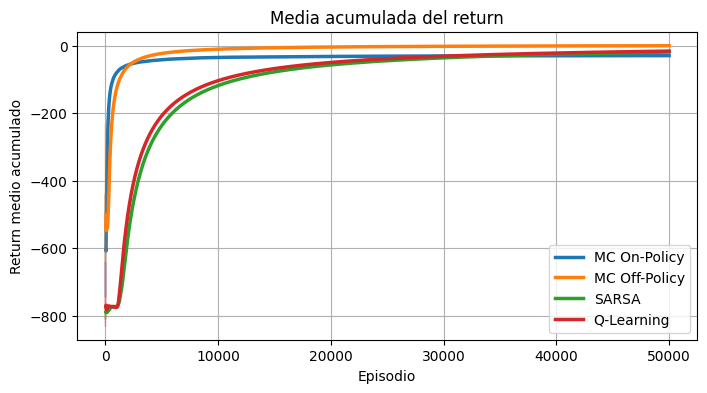

In [35]:
plot_all_results(final_results)

## Análisis de la proporción acumulada de éxitos

La primera gráfica muestra la evolución de la **proporción acumulada de episodios exitosos**, es decir, aquellos episodios en los que el agente logra **recoger al pasajero y dejarlo en su destino correctamente**.

A partir de la gráfica pueden observarse los siguientes comportamientos:

- **Q-Learning** y **Monte Carlo Off-Policy** aprenden más rápido y alcanzan tasas de éxito muy altas.
- **SARSA** también converge hacia una política eficaz, aunque lo hace de forma algo más gradual.
- **Monte Carlo On-Policy** es el método que aprende más lentamente y se mantiene por debajo del resto durante gran parte del entrenamiento.

Este comportamiento es coherente con lo esperado teóricamente. Los métodos **off-policy** y los métodos de **diferencias temporales (TD)** suelen aprender más rápido porque pueden actualizar los valores **sin esperar al final del episodio**, lo que permite propagar la información útil con mayor rapidez durante el entrenamiento.

En particular, **Q-Learning** y **Monte Carlo Off-Policy** terminan obteniendo resultados muy similares, ya que ambos son **off-policy** y aprenden directamente la **política óptima**. El pequeño **pico inicial de Q-Learning** puede explicarse por el uso del operador `max`, que permite **propagar rápidamente la recompensa** cuando el agente descubre una trayectoria correcta.

Por otro lado, **Monte Carlo On-Policy** aprende más lentamente porque **solo actualiza los valores al final de cada episodio**, mientras que los métodos TD realizan actualizaciones **paso a paso**, lo que acelera el proceso de aprendizaje.

En términos de velocidad de convergencia, el comportamiento observado sigue aproximadamente el siguiente patrón:

$$
\text{Q-Learning} \approx \text{MC Off-Policy} > \text{SARSA} > \text{MC On-Policy}
$$

## Análisis de la longitud de los episodios

En la segunda gráfica se muestra la **longitud de los episodios**, es decir, el número de pasos necesarios para completar cada episodio durante el entrenamiento de los distintos agentes.

Esta métrica permite evaluar **la eficiencia de la política aprendida**: cuanto **menos pasos necesita el agente para resolver la tarea**, más eficiente es la estrategia que ha aprendido.

A partir de la gráfica se observan los siguientes comportamientos:

- **SARSA** y **Q-Learning** reducen rápidamente el número de pasos por episodio.
- **Monte Carlo Off-Policy** también mejora de forma notable, aunque presenta algunos picos ocasionales.
- **Monte Carlo On-Policy** muestra el peor comportamiento relativo, con episodios más largos y mayor variabilidad durante el entrenamiento.

En general, **SARSA y Q-Learning aprenden políticas más eficientes en menos episodios**. Además, las curvas de los métodos que convergen correctamente se estabilizan aproximadamente alrededor de **13–15 pasos por episodio**, lo que corresponde aproximadamente a la **longitud de una trayectoria óptima en Taxi** para recoger al pasajero y dejarlo en su destino.

Estos resultados pueden explicarse por las diferencias en el mecanismo de actualización de cada algoritmo. Los métodos de **diferencias temporales (TD)**, como **SARSA** y **Q-Learning**, actualizan los valores **en cada paso**, lo que permite propagar rápidamente la información de recompensa a lo largo de la trayectoria. De esta forma, cuando el agente descubre una buena estrategia, puede **mejorar la política sin esperar al final del episodio**, acelerando el aprendizaje.

Por otro lado, **Monte Carlo Off-Policy** aprende a partir de **episodios completos**. Si durante la exploración el agente sigue una trayectoria poco eficiente, el episodio puede volverse muy largo antes de finalizar, lo que explica los **picos ocasionales observados en la gráfica**.

Finalmente, **Monte Carlo On-Policy** presenta **mayor variabilidad**, ya que también actualiza únicamente al final de cada episodio. En comparación, los métodos TD realizan actualizaciones más frecuentes, lo que suele producir un aprendizaje **más estable**.

## Análisis de la media acumulada del return

En la última gráfica se muestra la evolución de la **media acumulada del return** durante el entrenamiento para los cuatro agentes.

El return acumulado refleja el **rendimiento esperado de la política aprendida**. En el entorno **Taxi-v3**, un return más alto suele indicar una política más eficiente, ya que normalmente implica **menos pasos por episodio**, **menos penalizaciones por acciones incorrectas** y un **mayor número de episodios completados correctamente**.

A partir de las curvas observadas en la gráfica se pueden identificar los siguientes comportamientos:

- **Q-Learning** y **Monte Carlo Off-Policy** mejoran el return medio con mayor rapidez.
- **SARSA** también muestra una mejora clara, aunque su progreso es algo más gradual.
- **Monte Carlo On-Policy** tarda más en alcanzar valores comparables al resto de algoritmos y presenta un aprendizaje más lento.
- Al inicio del entrenamiento el **return presenta valores muy negativos**, ya que el agente actúa prácticamente al azar y cada acción, salvo finalizar correctamente el episodio, tiene una penalización.

A medida que el agente aprende, el return mejora progresivamente. En el caso de **Q-Learning**, el uso del operador `max` permite **propagar rápidamente la recompensa positiva** cuando el agente descubre una trayectoria correcta, lo que explica por qué su curva mejora antes que las demás.

Por su parte, **Monte Carlo Off-Policy** también aprende relativamente rápido porque **separa la política de exploración de la política objetivo**, lo que permite explorar mientras se aproxima directamente a la política óptima. En este método puede observarse un **pico inicial** en la gráfica, debido al uso de **importance sampling**, que al principio puede producir actualizaciones muy grandes cuando una trayectoria coincide con la política objetivo. A medida que avanza el entrenamiento, estas actualizaciones se reducen y la curva se estabiliza.

En contraste, **Monte Carlo On-Policy** aprende más lentamente porque **necesita episodios completos para realizar actualizaciones**, mientras que los métodos de **diferencias temporales (TD)**, como **SARSA** y **Q-Learning**, actualizan los valores en cada paso, lo que acelera el aprendizaje.

Al final del entrenamiento, los métodos que convergen correctamente terminan alcanzando **valores de return cercanos a cero**, lo que indica que el agente ha aprendido una política capaz de resolver el entorno de forma consistente.

## Análisis de los hiperparámetros utilizados

El rendimiento de los algoritmos implementados depende en gran medida de la elección de los **hiperparámetros**, ya que estos determinan el equilibrio entre **exploración del entorno**, **velocidad de aprendizaje** y **propagación de la recompensa**.

En este experimento se han utilizado principalmente los parámetros **ε (exploración)**, **γ (factor de descuento)** y **α (tasa de aprendizaje)**. Cada uno de ellos influye de forma diferente en el comportamiento de los algoritmos.


A continuación se muestra un resumen de los hiperparámetros utilizados en los distintos agentes implementados.

| Algoritmo | ε inicial | Decaimiento ε | γ (discount factor) | α (learning rate) | Otros |
|-----------|-----------|---------------|--------------------|------------------|------|
| Monte Carlo On-Policy | 0.4 | log decay opcional | 1.0 | — | First-Visit opcional |
| Monte Carlo Off-Policy | 0.1 | log decay opcional | 1.0 | — | Importance Sampling |
| SARSA | 1.0 | ε = min(1, c/(t+1)) | 0.99 | 0.1 | Política ε-greedy |
| Q-Learning | 1.0 | ε = min(1, c/(t+1)) | 0.99 | 0.1 | Actualización off-policy |

#### Exploración (ε)

El parámetro **ε** controla la exploración mediante una política **ε-greedy**. Con probabilidad ε el agente selecciona una acción aleatoria y con probabilidad \(1 - ε\) selecciona la acción greedy.

Esto ayuda a resolver el problema de **exploración vs explotación**, ya que al inicio del entrenamiento el agente explora diferentes trayectorias del entorno y, conforme ε disminuye, comienza a explotar la política aprendida.

En los métodos **SARSA y Q-Learning** se comienza con un valor alto de ε para favorecer la exploración inicial. Posteriormente se aplica un **decaimiento progresivo**, de modo que la política se vuelve cada vez más greedy a medida que el agente adquiere experiencia.

En los métodos **Monte Carlo**, la exploración se mantiene mediante políticas **ε-soft**, que garantizan que todas las acciones tengan una probabilidad mínima de ser seleccionadas.

#### Factor de descuento (γ)

El parámetro **γ** determina la importancia de las recompensas futuras en el cálculo del retorno:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + ...
$$

Valores de γ cercanos a **1** hacen que el agente tenga en cuenta recompensas a largo plazo, mientras que valores más pequeños priorizan recompensas inmediatas.

En el entorno **Taxi-v3**, la recompensa final se obtiene después de una secuencia de acciones (recoger y dejar al pasajero). Por este motivo se utilizan valores de **γ cercanos a 1**, lo que permite que la recompensa final se propague hacia los estados anteriores y facilite el aprendizaje de trayectorias eficientes.

#### Tasa de aprendizaje (α)

La tasa de aprendizaje **α** aparece en los algoritmos de **diferencias temporales** como **SARSA** y **Q-Learning**.

Las actualizaciones siguen la forma general:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha [\text{target} - Q(s,a)]
$$

Este parámetro determina cuánto se ajusta la estimación actual hacia la nueva información observada.

- Valores **altos** pueden provocar aprendizaje inestable.
- Valores **bajos** producen un aprendizaje más lento.

En este experimento se utiliza **α = 0.1**, que proporciona un buen equilibrio entre estabilidad y velocidad de aprendizaje.

En contraste, los métodos **Monte Carlo** no utilizan una tasa de aprendizaje fija, ya que los valores se estiman como **promedios de los retornos observados** a lo largo de los episodios.


In [ ]:


# Graba un vídeo de 1 episodio mostrando el comportamiento del agente en Taxi-v3 según el agente implementado
def record_agent_taxi(agent, name_prefix: str, filepath: str = "./video_taxi",
                      env_id: str = "Taxi-v3", seed: int = 42, max_steps: int = 300):

    Path(filepath).mkdir(parents=True, exist_ok=True)

    # Entorno con render RGB
    env_video = gym.make(env_id, render_mode="rgb_array")
    env_video.reset(seed=seed)

    # Wrapper para grabar vídeo
    env_video = RecordVideo(
        env_video,
        video_folder=filepath,
        name_prefix=name_prefix,
        episode_trigger=lambda e: True,
        disable_logger=True
    )

    # Evaluación sin exploración
    old_eps = getattr(agent, "epsilon", None)
    if old_eps is not None:
        agent.epsilon = 0.0

    state, _ = env_video.reset(seed=seed)
    total_reward = 0.0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:

        if hasattr(agent, "get_greedy_action"):
            action = agent.get_greedy_action(state)
        else:
            action = agent.get_action(state)

        state, reward, terminated, truncated, _ = env_video.step(action)
        total_reward += reward
        steps += 1

    env_video.close()

    if old_eps is not None:
        agent.epsilon = old_eps

    print(f"Vídeo guardado en: {filepath}")
    print(f"Reward total del episodio: {total_reward}")
    print(f"Número de pasos: {steps}")

    mp4s = sorted(Path(filepath).glob(f"{name_prefix}*.mp4"),
                  key=lambda p: p.stat().st_mtime, reverse=True)

    if len(mp4s) > 0:
        display(Video(str(mp4s[0]), embed=True, width=520))
    else:
        print("No se encontró el vídeo. Revisa el wrapper RecordVideo y permisos de escritura.")


# Monte Carlo On-Policy
print("Ejecucion de Monte Carlo On-Policy")
record_agent_taxi(
    agentMonteCarloOnPolicy,
    name_prefix="taxi-mc-on-policy",
    filepath="./video_taxi",
    seed=seed
)

# Monte Carlo Off-Policy
print("Ejecucion de Monte Carlo Off-Policy")
record_agent_taxi(
    agentMonteCarloOffPolicy,
    name_prefix="taxi-mc-off-policy",
    filepath="./video_taxi",
    seed=seed
)

# SARSA
print("Ejecucion de SARSA")
record_agent_taxi(
    agentSARSA,
    name_prefix="taxi-sarsa",
    filepath="./video_taxi",
    seed=seed
)

# Q-Learning
print("Ejecucion de Q-Learning")
record_agent_taxi(
    agentQLearning,
    name_prefix="taxi-q-learning",
    filepath="./video_taxi",
    seed=seed
)


Ejecucion de Monte Carlo On-Policy
Vídeo guardado en: ./video_taxi
Reward total del episodio: 8.0
Número de pasos: 13


Ejecucion de Monte Carlo Off-Policy
Vídeo guardado en: ./video_taxi
Reward total del episodio: 8.0
Número de pasos: 13


Ejecucion de SARSA
Vídeo guardado en: ./video_taxi
Reward total del episodio: 8.0
Número de pasos: 13


Ejecucion de Q-Learning
Vídeo guardado en: ./video_taxi
Reward total del episodio: 8.0
Número de pasos: 13


## Conclusión final

En este notebook se han comparado cuatro métodos clásicos de **aprendizaje por refuerzo tabular**:  
**Monte Carlo On-Policy, Monte Carlo Off-Policy, SARSA y Q-Learning**, utilizando el entorno **Taxi-v3**.

A partir del análisis de las tres métricas estudiadas: **proporción acumulada de éxitos**, **longitud de los episodios** y **media acumulada del return** se observan diferencias claras en la convergencia y estabilidad del aprendizaje entre los distintos algoritmos.

Los resultados muestran que **Q-Learning** y **Monte Carlo Off-Policy** son los métodos que alcanzan antes políticas eficaces. Ambos consiguen tasas de éxito altas en menos episodios y mejoran el rendimiento medio con mayor rapidez. Esto es coherente con la teoría, ya que al ser **métodos off-policy** pueden aproximar directamente la **política óptima**. En particular, **Q-Learning** destaca por su rapidez inicial de mejora gracias al operador `max`, que permite propagar rápidamente la recompensa cuando se descubre una trayectoria correcta.

Por su parte, **SARSA** también converge hacia una política eficaz, aunque lo hace de forma más gradual al ser un método **on-policy**, que aprende evaluando la política que realmente ejecuta durante la exploración.

En cambio, **Monte Carlo On-Policy** presenta el aprendizaje más lento y mayor variabilidad. Esto se debe a que los métodos Monte Carlo solo actualizan al final de cada episodio, mientras que los métodos de **diferencias temporales (TD)** como **SARSA** y **Q-Learning** actualizan los valores en cada paso, lo que acelera la propagación de la información de recompensa.

El análisis de la longitud de los episodios muestra además que los métodos que convergen correctamente terminan estabilizándose alrededor de **13–15 pasos**, lo que corresponde aproximadamente a la trayectoria óptima del entorno **Taxi-v3**.

Además del análisis cuantitativo, al final del notebook se incluyen **vídeos de evaluación de los agentes entrenados**. En ellos se ejecuta un episodio utilizando la política greedy aprendida por cada algoritmo, lo que permite observar de forma cualitativa cómo los agentes aplican la estrategia aprendida para recoger al pasajero y llevarlo a su destino.

En conjunto, los resultados obtenidos coinciden con lo esperado teóricamente: los métodos basados en **diferencias temporales y aprendizaje off-policy**, especialmente **Q-Learning**, resultan efectivos para aprender políticas eficientes en el entorno **Taxi-v3**.